## Imports

This section loads the required libraries.

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Dataset paths

This section defines the training and test directories.

In [2]:
data_dir = Path("../data/raw/fer2013")
train_dir = data_dir / "train"
test_dir = data_dir / "test"

train_classes = sorted([f.name for f in train_dir.iterdir() if f.is_dir()])
test_classes = sorted([f.name for f in test_dir.iterdir() if f.is_dir()])

print("Train classes:", train_classes)
print("Test classes:", test_classes)

Train classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## LBP settings

This section defines the LBP parameters.

In [3]:
radius = 1
n_points = 8 * radius
method = "uniform"

print("Radius:", radius)
print("Number of points:", n_points)
print("Method:", method)

Radius: 1
Number of points: 8
Method: uniform


## Feature extraction functions

This section defines image loading and LBP feature extraction.

In [7]:
def load_grayscale_image(image_path, image_size=(48, 48)):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, image_size)
    return image


def extract_lbp_features(image, radius=1, n_points=8, method="uniform"):
    lbp = local_binary_pattern(image, n_points, radius, method=method)
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins + 1), range=(0, n_bins))
    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-6)
    return hist

## Training feature extraction

This section extracts LBP features from the training images.

In [8]:
X_train = []
y_train = []

for class_name in train_classes:
    class_path = train_dir / class_name
    image_paths = list(class_path.glob("*"))
    
    for image_path in image_paths:
        image = load_grayscale_image(image_path)
        features = extract_lbp_features(
            image,
            radius=radius,
            n_points=n_points,
            method=method
        )
        X_train.append(features)
        y_train.append(class_name)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (28709, 10)
y_train shape: (28709,)


## Test feature extraction

This section extracts LBP features from the test images.

In [9]:
X_test = []
y_test = []

for class_name in test_classes:
    class_path = test_dir / class_name
    image_paths = list(class_path.glob("*"))
    
    for image_path in image_paths:
        image = load_grayscale_image(image_path)
        features = extract_lbp_features(
            image,
            radius=radius,
            n_points=n_points,
            method=method
        )
        X_test.append(features)
        y_test.append(class_name)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (7178, 10)
y_test shape: (7178,)


## Model training

This section trains the LBP + SVM model.

In [10]:
lbp_svm = LinearSVC(random_state=42, max_iter=5000)
lbp_svm.fit(X_train, y_train)

print("Model training is complete.")

Model training is complete.


## Prediction and evaluation

This section generates predictions and evaluates the model.

In [11]:
y_pred = lbp_svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.2570


In [16]:
X_test = []
y_test = []
test_image_paths = []

for class_name in test_classes:
    class_path = test_dir / class_name
    image_paths = list(class_path.glob("*"))
    
    for image_path in image_paths:
        image = load_grayscale_image(image_path)
        features = extract_lbp_features(
            image,
            radius=radius,
            n_points=n_points,
            method=method
        )
        X_test.append(features)
        y_test.append(class_name)
        test_image_paths.append(image_path)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Stored test image paths:", len(test_image_paths))

X_test shape: (7178, 10)
y_test shape: (7178,)
Stored test image paths: 7178


## Confusion matrix

This section shows the class-wise prediction results.

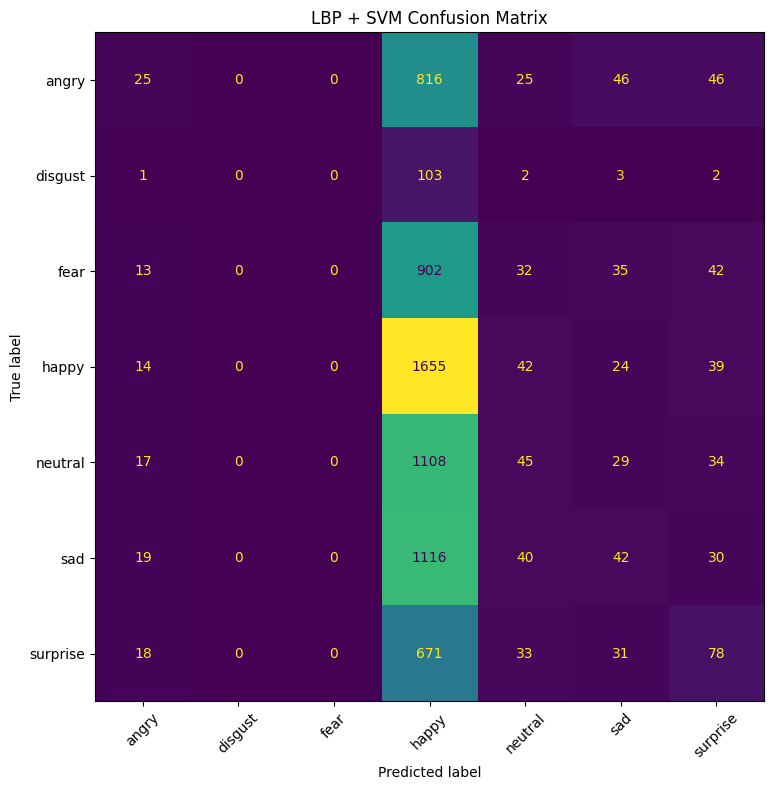

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=test_classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("LBP + SVM Confusion Matrix")
plt.tight_layout()
plt.show()

## Prediction summary

This section shows a few sample predictions.

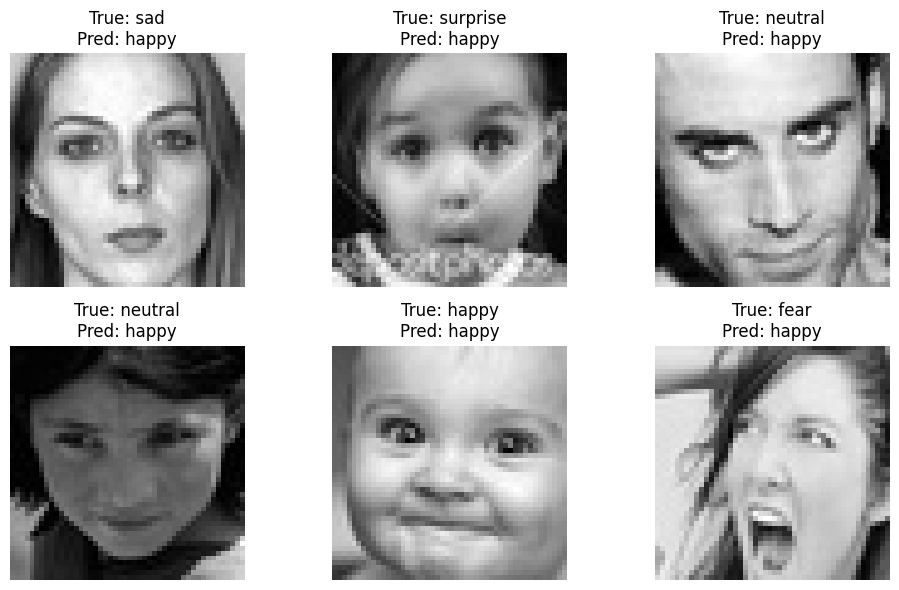

In [18]:
sample_indices = np.random.choice(len(X_test), size=6, replace=False)

plt.figure(figsize=(10, 6))

for i, idx in enumerate(sample_indices):
    image = load_grayscale_image(test_image_paths[idx])

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observation

The LBP + SVM model achieves low classification accuracy and shows strong bias towards predicting the "happy" class. Most samples from other classes such as angry, fear, sad, and neutral are misclassified as happy. The confusion matrix indicates poor class separation, especially for minority classes like disgust. This suggests that LBP features are not sufficiently discriminative for capturing subtle differences between facial expressions in this dataset.

## Report note

The LBP + SVM model is used as a traditional feature-based baseline for facial emotion classification. The results show limited performance, with a tendency to predict dominant classes and difficulty in distinguishing similar expressions. This highlights the limitations of handcrafted texture features such as LBP for complex emotion recognition tasks and motivates the use of more advanced feature representations.